In [51]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.feature_selection import RFE
from sklearn.metrics import mean_squared_error, r2_score

In [52]:
# Task 1
diabetes = load_diabetes()
X = pd.DataFrame(diabetes.data, columns=diabetes.feature_names)
y = pd.Series(diabetes.target, name='progression')

print("Feature Description:\n", X.describe())
print("\nTarget Description:\n", y.describe())
print("\nFeature Names:", diabetes.feature_names)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"\nTraining set size: {X_train.shape[0]}")
print(f"Testing set size: {X_test.shape[0]}")

Feature Description:
                 age           sex           bmi            bp            s1  \
count  4.420000e+02  4.420000e+02  4.420000e+02  4.420000e+02  4.420000e+02   
mean  -2.511817e-19  1.230790e-17 -2.245564e-16 -4.797570e-17 -1.381499e-17   
std    4.761905e-02  4.761905e-02  4.761905e-02  4.761905e-02  4.761905e-02   
min   -1.072256e-01 -4.464164e-02 -9.027530e-02 -1.123988e-01 -1.267807e-01   
25%   -3.729927e-02 -4.464164e-02 -3.422907e-02 -3.665608e-02 -3.424784e-02   
50%    5.383060e-03 -4.464164e-02 -7.283766e-03 -5.670422e-03 -4.320866e-03   
75%    3.807591e-02  5.068012e-02  3.124802e-02  3.564379e-02  2.835801e-02   
max    1.107267e-01  5.068012e-02  1.705552e-01  1.320436e-01  1.539137e-01   

                 s2            s3            s4            s5            s6  
count  4.420000e+02  4.420000e+02  4.420000e+02  4.420000e+02  4.420000e+02  
mean   3.918434e-17 -5.777179e-18 -9.042540e-18  9.293722e-17  1.130318e-17  
std    4.761905e-02  4.761905e-0

In [53]:
# Task 2
model = LinearRegression()

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

r2 = r2_score(y_test, y_pred)
print(f"R^2 Score: {r2}")

R^2 Score: 0.45260276297191937


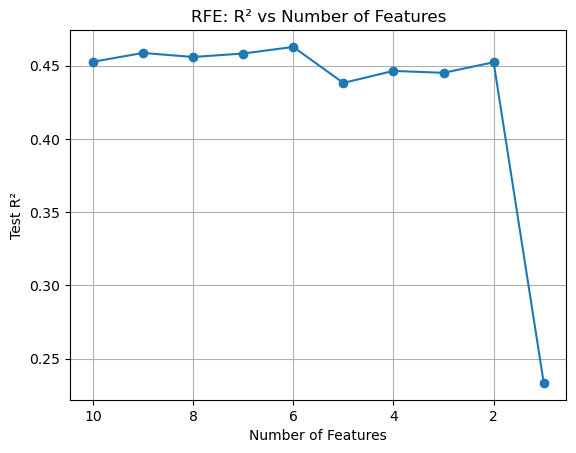

Optimal number of features: 10
Selected features: [np.str_('age'), np.str_('sex'), np.str_('bmi'), np.str_('bp'), np.str_('s1'), np.str_('s2'), np.str_('s3'), np.str_('s4'), np.str_('s5'), np.str_('s6')]


In [54]:
# Task 3
r2_scores = []
feature_counts = []
selected_features_list = []
coef_history = []

p = X.shape[1]

for k in range(p, 0, -1):
    rfe = RFE(estimator=LinearRegression(), n_features_to_select=k)
    rfe.fit(X_train, y_train)

    selected_mask = rfe.support_
    selected_features = np.array(feature_names)[selected_mask]

    model = LinearRegression()
    model.fit(X_train[selected_features], y_train)

    predictions = model.predict(X_test[selected_features])
    r2 = r2_score(y_test, predictions)

    r2_scores.append(r2)
    feature_counts.append(k)
    selected_features_list.append(list(selected_features))

    coef_series = pd.Series(np.nan, index=feature_names)
    coef_series[selected_features] = model.coef_
    coef_history.append(coef_series)

plt.figure()
plt.plot(feature_counts, r2_scores, marker="o")
plt.gca().invert_xaxis()
plt.xlabel("Number of Features")
plt.ylabel("Test R²")
plt.title("RFE: R² vs Number of Features")
plt.grid(True)
plt.show()

threshold = 0.01
optimal_n = feature_counts[0]

for i in range(1, len(r2_scores)):
    improvement = r2_scores[i] - r2_scores[i-1]

    if improvement >= threshold:
        optimal_n = feature_counts[i]
    else:
        break

optimal_index = feature_counts.index(optimal_n)
optimal_features = selected_features_list[optimal_index]

print("Optimal number of features:", optimal_n)
print("Selected features:", optimal_features)

In [55]:
# Task 4.1
coef_df = pd.DataFrame(coef_history)
coef_df.index = feature_counts
coef_df.index.name = "n_features"
display(coef_df.round(4))

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6
n_features,,,,,,,,,,
10,37.904,-241.9644,542.4288,347.7038,-931.4888,518.0623,163.4200,275.3179,736.1989,48.6707
9,NaN,-236.6496,542.7995,354.2114,-936.3506,528.7966,167.8004,270.3965,744.4474,53.3505
8,NaN,-233.7547,550.7444,363.7918,-947.8231,541.5858,172.2506,277.7411,761.9212,NaN
7,NaN,-235.3642,551.8664,362.3561,-660.6432,343.3481,NaN,185.1408,664.7746,NaN
6,NaN,-215.2674,557.3142,350.1787,-851.5157,591.0933,NaN,NaN,803.1213,NaN
5,NaN,NaN,597.8927,306.6479,-655.5606,409.6222,NaN,NaN,728.6436,NaN
4,NaN,NaN,691.4601,NaN,-592.9779,362.9503,NaN,NaN,783.1685,NaN
3,NaN,NaN,737.6856,NaN,-228.3399,NaN,NaN,NaN,680.2247,NaN
2,NaN,NaN,732.1090,NaN,NaN,NaN,NaN,NaN,562.2265,NaN


# 4.2
BMI, s5, and bp were identified as the most critical predictors, showing the highest stability and coefficient values throughout the elimination process. It shows these features represent key physiological and biochemical indicators.

# 4.3
Although the initial model assigned large coefficients to redundant variables such as s1, RFE eliminated them and retained more independent and robust predictors. This reduced the model from 10 features to a simpler set.